# Quick EDA of Ad Copy Data
Source: Meta Ad Library, accessed via API. Performance metrics not publicly available online: will generate realistic synthetic metrics to train models and make improvements via LLM generation. Pipeline is built to take in formatted production data when it becomes available.

In [ ]:
# Load in csv data (assumed enrichment has already been done)
""" Steps to load in enriched csv data:
    1. run build_ad_dataset.py -> scrapes meta ad library for existing ad copies and adds synthetic clicks/impressions information
    2. run compute_metrics.py -> enriches result of step 1 by adding additional metrics and high_performer tag (to be used by LLM)
"""
import pandas as pd
ad_copy_df = pd.read_csv("../data/pipeline/meta_ads_with_metrics.csv")
ad_copy_df.head(5)

,ad_id,campaign_id,headline_text,body_text,call_to_action,platform,placement,ad_format,category,impressions,clicks,conversions,spend,ctr,cvr,cpc,cpa,high_performer
0,meta_ad_001,NaN,Save 20% on Running Shoes Today,Limited-time offer on our best-selling running...,Shop Now,facebook,NaN,image,ecommerce,58210,913,124,834.71,0.015685,0.135816,0.914250,6.731532,1
1,meta_ad_002,NaN,Organize Your Work in One Place,Our project management platform helps remote t...,Start Free Trial,instagram,NaN,image,saas,42135,214,31,289.50,0.005079,0.144860,1.352804,9.338710,0
2,meta_ad_003,NaN,Master Data Analytics in 8 Weeks,Join our intensive online bootcamp and build a...,Apply Now,facebook,NaN,video,education,30112,452,46,512.39,0.015011,0.101770,1.133606,11.138913,1
3,meta_ad_004,NaN,Fresh Deals on Home Office Gear,"Upgrade your desk setup with ergonomic chairs,...",Shop Deals,facebook,NaN,image,ecommerce,76544,1023,138,954.80,0.013365,0.134897,0.933333,6.918841,0
4,meta_ad_005,NaN,The CRM Built for Small Teams,"Track leads, automate follow-ups, and close mo...",Book Demo,instagram,NaN,video,saas,38950,198,22,314.27,0.005083,0.111111,1.587222,14.285000,0


In [3]:
sample_ads = pd.read_csv("../data/sample_ads.csv")
sample_ads.head(5)
# Source: https://huggingface.co/datasets/PeterBrendan/Ads_Creative_Ad_Copy_Programmatic

,text,dimensions
0,AGF\r\nAMAZING GRACE FELLOWSHIP\r\n1061 EASTLA...,"(300, 250)"
1,NO\r\nZOLUCKY\r\n- UP TO -\r\n50%\r\nshop now,"(728, 90)"
2,Academy\r\nSPORTS+OUTDOORS\r\nPRESENTS\r\n::HA...,"(160, 600)"
3,TIME TO\r\nOREGON'S\r\nMT.HOOD\r\nTERRITORY\r\...,"(728, 90)"
4,FARMERS\r\nINSURANCE\r\nJeremy Belcourt\r\nCON...,"(728, 90)"


In [3]:
print('Shape of the dataframe:', ad_copy_df.shape)

Shape of the dataframe: (10, 18)


In [4]:
ad_copy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ad_id           10 non-null     object 
 1   campaign_id     0 non-null      float64
 2   headline_text   10 non-null     object 
 3   body_text       10 non-null     object 
 4   call_to_action  10 non-null     object 
 5   platform        10 non-null     object 
 6   placement       0 non-null      float64
 7   ad_format       10 non-null     object 
 8   category        10 non-null     object 
 9   impressions     10 non-null     int64  
 10  clicks          10 non-null     int64  
 11  conversions     10 non-null     int64  
 12  spend           10 non-null     float64
 13  ctr             10 non-null     float64
 14  cvr             10 non-null     float64
 15  cpc             10 non-null     float64
 16  cpa             10 non-null     float64
 17  high_performer  10 non-null     int64 

In [5]:
ad_copy_df.describe()

,campaign_id,placement,impressions,clicks,conversions,spend,ctr,cvr,cpc,cpa,high_performer
count,0.0,0.0,10.000000,10.000000,10.0000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,NaN,NaN,47292.000000,544.700000,66.7000,568.523000,0.011263,0.118646,1.135911,9.792764,0.300000
std,NaN,NaN,15951.401144,308.856691,43.7113,251.618672,0.004258,0.017428,0.219226,2.462419,0.483046
min,NaN,NaN,27640.000000,198.000000,22.0000,289.500000,0.005079,0.092040,0.914250,6.731532,0.000000
25%,NaN,NaN,34704.250000,296.000000,32.5000,363.795000,0.007370,0.106407,0.975608,8.044177,0.000000
50%,NaN,NaN,43822.500000,427.000000,43.5000,469.970000,0.012720,0.115135,1.062459,9.530818,0.000000
75%,NaN,NaN,59050.000000,825.750000,100.7500,810.842500,0.014339,0.134166,1.280137,11.451282,0.750000
max,NaN,NaN,76544.000000,1023.000000,138.0000,954.800000,0.015685,0.144860,1.587222,14.285000,1.000000


In [7]:
print('Missing values per column:')
ad_copy_df.isnull().sum()

Missing values per column:


ad_id              0
campaign_id       10
headline_text      0
body_text          0
call_to_action     0
platform           0
placement         10
ad_format          0
category           0
impressions        0
clicks             0
conversions        0
spend              0
ctr                0
cvr                0
cpc                0
cpa                0
high_performer     0
dtype: int64

In [8]:
print('Value counts for categorical columns:')
categorical_cols = ['platform', 'ad_format', 'category', 'high_performer']
for col in categorical_cols:
    print(f'\n{col}:')
    print(ad_copy_df[col].value_counts())

Value counts for categorical columns:

platform:
platform
facebook     6
instagram    4
Name: count, dtype: int64

ad_format:
ad_format
image    7
video    3
Name: count, dtype: int64

category:
category
ecommerce    4
saas         3
education    3
Name: count, dtype: int64

high_performer:
high_performer
0    7
1    3
Name: count, dtype: int64


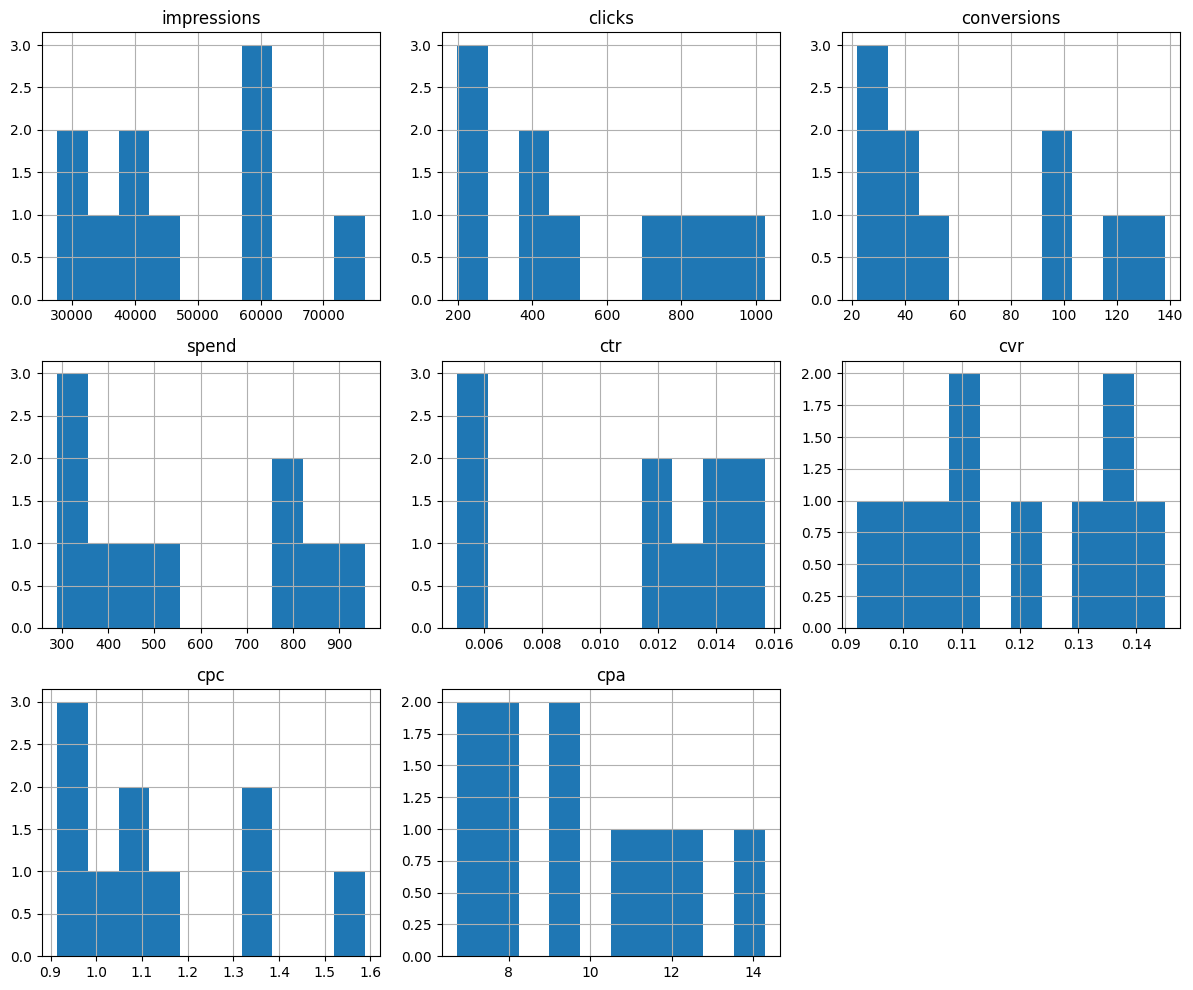

In [11]:
import matplotlib.pyplot as plt
numerical_cols = ['impressions', 'clicks', 'conversions', 'spend', 'ctr', 'cvr', 'cpc', 'cpa']
ad_copy_df[numerical_cols].hist(figsize=(12, 10), bins=10)
plt.tight_layout()
plt.show()

In [13]:
print('Correlation matrix for numerical columns:')
ad_copy_df[numerical_cols].corr()

Correlation matrix for numerical columns:


,impressions,clicks,conversions,spend,ctr,cvr,cpc,cpa
impressions,1.000000,0.815356,0.869817,0.841873,0.196914,0.687946,-0.428960,-0.703164
clicks,0.815356,1.000000,0.987353,0.992791,0.723996,0.428027,-0.823911,-0.848547
conversions,0.869817,0.987353,1.000000,0.983134,0.636199,0.553168,-0.762766,-0.873878
spend,0.841873,0.992791,0.983134,1.000000,0.686267,0.439348,-0.776471,-0.819879
ctr,0.196914,0.723996,0.636199,0.686267,1.000000,-0.098659,-0.902391,-0.613170
cvr,0.687946,0.428027,0.553168,0.439348,-0.098659,1.000000,-0.123292,-0.672085
cpc,-0.428960,-0.823911,-0.762766,-0.776471,-0.902391,-0.123292,1.000000,0.814917
cpa,-0.703164,-0.848547,-0.873878,-0.819879,-0.613170,-0.672085,0.814917,1.000000


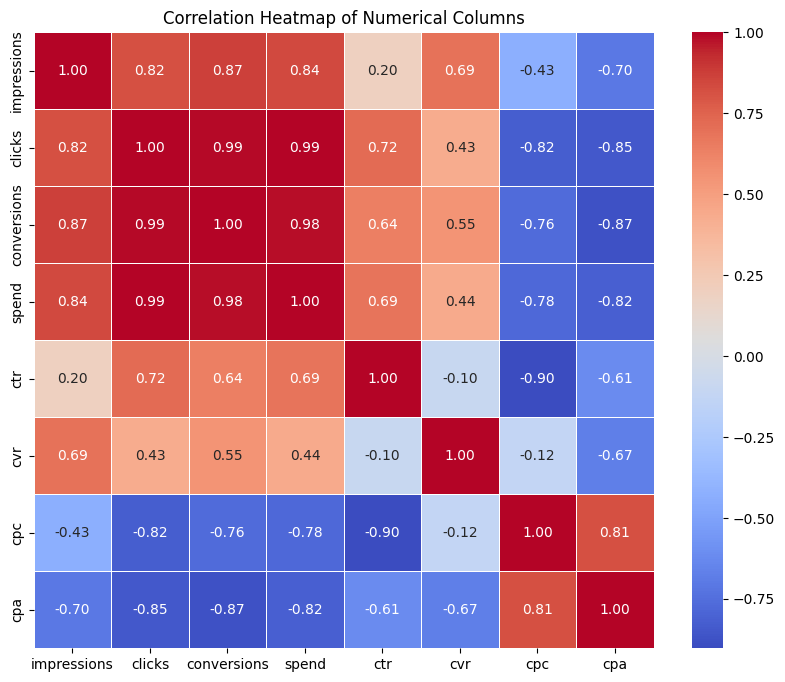

In [15]:
import seaborn as sns
corr_matrix = ad_copy_df[numerical_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Columns')
plt.show()